This notebook implements an oracle-style combiner experiment.

- The trained Model 3 V3 DINOv2 overhead RGB model is used as the carbohydrate specialist.
- The true dish mass is used directly instead of a predicted mass model.
- A final combiner head is trained on `[rgb_carb_pred, true_mass]` to output a single carbohydrate estimate.

This tests whether mass is useful in principle for carbohydrate estimation when the mass signal is perfect.

Prerequisits

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

Settings

In [ ]:
RGB_IMG_HEIGHT = 224
RGB_IMG_WIDTH  = 224
BATCH_SIZE = 16
AUTOTUNE   = tf.data.AUTOTUNE
COMBINER_EPOCHS = 300
COMBINER_LR = 1e-3
SEED = 42

tf.random.set_seed(SEED)
np.random.seed(SEED)

DATASET_DIR = Path("/content/drive/MyDrive/Speciale/dataset/nutrition5k_compactV3")
METADATA_CSV = Path("/content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_mass_split_metadata.csv")

MODEL3_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_3_V3_DINO_RGB_only")
MODEL10_DIR = Path("/content/drive/MyDrive/Speciale/Models/Model_10_ViT_overhead_RGB_plus_actual_mass")
MODEL10_DIR.mkdir(parents=True, exist_ok=True)

PREP_DIR = MODEL10_DIR / "prep_files"
PREP_DIR.mkdir(parents=True, exist_ok=True)

MODEL3_FINAL_MODEL = MODEL3_DIR / "final_model.keras"

Loading dataset

In [ ]:
df = pd.read_csv(METADATA_CSV)

print("Loaded file:", METADATA_CSV)
print("Shape before processing:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

required_cols = ["dish_id", "total_carb", "total_mass", "split"]
missing_cols = [c for c in required_cols if c not in df.columns]

if len(missing_cols) > 0:
    raise ValueError(f"Missing required columns: {missing_cols}")

Loaded file: /content/drive/MyDrive/Speciale/dataset/prepared_overhead_rgb_dataset/dish_carb_mass_split_metadata.csv
Shape before processing: (3262, 5)
Columns: ['dish_id', 'total_mass', 'total_carb', 'split', 'source_cafe']


,dish_id,total_mass,total_carb,split,source_cafe
0,dish_1556575327,152.0,10.618,test,cafe1
1,dish_1557861216,1.0,0.000,test,cafe1
2,dish_1557862345,63.0,0.000,test,cafe1
3,dish_1557862696,77.0,3.850,test,cafe1
4,dish_1557862738,118.0,0.000,test,cafe1


In [ ]:
df["rgb_path"] = df["dish_id"].apply(
    lambda d: str(DATASET_DIR / str(d) / "overhead" / "rgb.png")
)

df["rgb_exists"] = df["rgb_path"].apply(lambda p: Path(p).exists())

print("Missing RGB images:", (~df["rgb_exists"]).sum())

Missing RGB images: 0


In [ ]:
def file_size_or_minus1(path_str):
    p = Path(path_str)
    try:
        return p.stat().st_size
    except Exception:
        return -1

df["rgb_size"] = df["rgb_path"].apply(file_size_or_minus1)

print("Empty RGB files:", (df["rgb_size"] <= 0).sum())

df = df[
    (df["rgb_exists"]) &
    (df["rgb_size"] > 0)
].copy()

print("\nRemaining samples after RGB filtering:")
print(df["split"].value_counts(dropna=False))
print("Total remaining:", len(df))

display(df.head())

Empty RGB files: 0

Remaining samples after RGB filtering:
split
train    2421
test      507
val       334
Name: count, dtype: int64
Total remaining: 3262


,dish_id,total_mass,total_carb,split,source_cafe,rgb_path,rgb_exists,rgb_size
0,dish_1556575327,152.0,10.618,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,548259
1,dish_1557861216,1.0,0.000,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,353804
2,dish_1557862345,63.0,0.000,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,407501
3,dish_1557862696,77.0,3.850,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,391780
4,dish_1557862738,118.0,0.000,test,cafe1,/content/drive/MyDrive/Speciale/dataset/nutrit...,True,412017


In [ ]:
train_df = df[df["split"] == "train"].copy().reset_index(drop=True)
val_df   = df[df["split"] == "val"].copy().reset_index(drop=True)
test_df  = df[df["split"] == "test"].copy().reset_index(drop=True)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

train_csv = PREP_DIR / "train_model10_rgb_mass.csv"
val_csv   = PREP_DIR / "val_model10_rgb_mass.csv"
test_csv  = PREP_DIR / "test_model10_rgb_mass.csv"
full_csv  = PREP_DIR / "full_model10_rgb_mass.csv"

train_df.to_csv(train_csv, index=False)
val_df.to_csv(val_csv, index=False)
test_df.to_csv(test_csv, index=False)
df.to_csv(full_csv, index=False)

print("Saved:")
print(train_csv)
print(val_csv)
print(test_csv)
print(full_csv)

Train: 2421
Val:   334
Test:  507
Saved:
/content/drive/MyDrive/Speciale/Models/Model_10_ViT_overhead_RGB_plus_actual_mass/prep_files/train_model10_rgb_mass.csv
/content/drive/MyDrive/Speciale/Models/Model_10_ViT_overhead_RGB_plus_actual_mass/prep_files/val_model10_rgb_mass.csv
/content/drive/MyDrive/Speciale/Models/Model_10_ViT_overhead_RGB_plus_actual_mass/prep_files/test_model10_rgb_mass.csv
/content/drive/MyDrive/Speciale/Models/Model_10_ViT_overhead_RGB_plus_actual_mass/prep_files/full_model10_rgb_mass.csv


In [ ]:
def load_rgb_image(rgb_path):
    image = tf.io.read_file(rgb_path)
    image = tf.image.decode_png(image, channels=3)

    image = tf.image.resize_with_pad(
        image,
        target_height=RGB_IMG_HEIGHT,
        target_width=RGB_IMG_WIDTH,
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=True
    )

    image = tf.cast(image, tf.float32)
    return image


def load_rgb_and_label(rgb_path, label):
    rgb = load_rgb_image(rgb_path)
    label = tf.cast(label, tf.float32)
    return {"rgb_input": rgb}, label


def make_rgb_dataset(dataframe, batch_size=BATCH_SIZE, shuffle=False):
    rgb_paths = dataframe["rgb_path"].astype(str).values
    labels = dataframe["total_carb"].values.astype("float32")

    ds = tf.data.Dataset.from_tensor_slices((rgb_paths, labels))

    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)

    ds = ds.map(load_rgb_and_label, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds

In [ ]:
train_rgb_dataset = make_rgb_dataset(train_df, batch_size=BATCH_SIZE, shuffle=False)
val_rgb_dataset   = make_rgb_dataset(val_df, batch_size=BATCH_SIZE, shuffle=False)
test_rgb_dataset  = make_rgb_dataset(test_df, batch_size=BATCH_SIZE, shuffle=False)

for batch_inputs, batch_labels in train_rgb_dataset.take(1):
    print("Input keys:", batch_inputs.keys())
    print("RGB shape:", batch_inputs["rgb_input"].shape)
    print("Labels shape:", batch_labels.shape)

Input keys: dict_keys(['rgb_input'])
RGB shape: (16, 224, 224, 3)
Labels shape: (16,)


Loading trained RGB model

In [ ]:
if MODEL3_FINAL_MODEL.exists():
    rgb_carb_model = keras.models.load_model(MODEL3_FINAL_MODEL)
    print("Loaded Model 3 V3 from final_model.keras")
else:
    raise FileNotFoundError(
        f"Could not find Model 3 V3 final model at: {MODEL3_FINAL_MODEL}. "
        "Run and save Model 3 V3 first."
    )

rgb_carb_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 896 variables whereas the saved optimizer has 886 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Loaded Model 3 V3 from final_model.keras


Model: "rgb_only_dino_vit_regressor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov2_image_converter          │ (None, 224, 224, 3)    │             0 │
│ (DINOV2ImageConverter)          │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dinov2_backbone                 │ (None, 257, 1024)      │   304,631,808 │
│ (DINOV2Backbone)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_2           │ (None, 257, 1024)      │         2,048 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_pool                      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_64 (Dropout)            │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_65 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ carb_output (Dense)             │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 911,932,549 (3.40 GB)

 Trainable params: 303,509,889 (1.13 GB)

 Non-trainable params: 1,402,880 (5.35 MB)

 Optimizer params: 607,019,780 (2.26 GB)

Generating predictions from RGB model

In [ ]:
train_rgb_carb_preds = rgb_carb_model.predict(train_rgb_dataset, verbose=1).reshape(-1)
val_rgb_carb_preds   = rgb_carb_model.predict(val_rgb_dataset, verbose=1).reshape(-1)
test_rgb_carb_preds  = rgb_carb_model.predict(test_rgb_dataset, verbose=1).reshape(-1)

print(train_rgb_carb_preds.shape)
print(val_rgb_carb_preds.shape)
print(test_rgb_carb_preds.shape)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(16, 224, 224, 3))
  warnings.warn(msg)


151/152 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: {'images': 'images'}
Received: inputs=Tensor(shape=(None, 224, 224, 3))
  warnings.warn(msg)


152/152 ━━━━━━━━━━━━━━━━━━━━ 465s 3s/step
21/21 ━━━━━━━━━━━━━━━━━━━━ 62s 3s/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 94s 3s/step
(2421,)
(334,)
(507,)


Building combiner model

In [ ]:
train_combiner_df = train_df[["dish_id", "total_carb", "total_mass"]].copy().reset_index(drop=True)
val_combiner_df   = val_df[["dish_id", "total_carb", "total_mass"]].copy().reset_index(drop=True)
test_combiner_df  = test_df[["dish_id", "total_carb", "total_mass"]].copy().reset_index(drop=True)

train_combiner_df["rgb_carb_pred"] = train_rgb_carb_preds
val_combiner_df["rgb_carb_pred"]   = val_rgb_carb_preds
test_combiner_df["rgb_carb_pred"]  = test_rgb_carb_preds

display(train_combiner_df.head())


,dish_id,total_carb,total_mass,rgb_carb_pred
0,dish_1556572657,2.268,36.0,2.041218
1,dish_1556573514,1.219,23.0,1.584430
2,dish_1556575014,3.906,62.0,3.690660
3,dish_1556575083,5.760,64.0,5.872280
4,dish_1556575124,0.952,28.0,0.847786


In [ ]:
train_combiner_csv = MODEL10_DIR / "train_combiner_features_rgb_plus_true_mass.csv"
val_combiner_csv   = MODEL10_DIR / "val_combiner_features_rgb_plus_true_mass.csv"
test_combiner_csv  = MODEL10_DIR / "test_combiner_features_rgb_plus_true_mass.csv"

train_combiner_df.to_csv(train_combiner_csv, index=False)
val_combiner_df.to_csv(val_combiner_csv, index=False)
test_combiner_df.to_csv(test_combiner_csv, index=False)

print(train_combiner_csv)
print(val_combiner_csv)
print(test_combiner_csv)


/content/drive/MyDrive/Speciale/Models/Model_10_ViT_overhead_RGB_plus_actual_mass/train_combiner_features_rgb_plus_true_mass.csv
/content/drive/MyDrive/Speciale/Models/Model_10_ViT_overhead_RGB_plus_actual_mass/val_combiner_features_rgb_plus_true_mass.csv
/content/drive/MyDrive/Speciale/Models/Model_10_ViT_overhead_RGB_plus_actual_mass/test_combiner_features_rgb_plus_true_mass.csv


In [ ]:
X_train = train_combiner_df[["rgb_carb_pred", "total_mass"]].values.astype("float32")
y_train = train_combiner_df["total_carb"].values.astype("float32")

X_val = val_combiner_df[["rgb_carb_pred", "total_mass"]].values.astype("float32")
y_val = val_combiner_df["total_carb"].values.astype("float32")

X_test = test_combiner_df[["rgb_carb_pred", "total_mass"]].values.astype("float32")
y_test = test_combiner_df["total_carb"].values.astype("float32")

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "y_val:  ", y_val.shape)
print("X_test: ", X_test.shape, "y_test: ", y_test.shape)


X_train: (2421, 2) y_train: (2421,)
X_val:   (334, 2) y_val:   (334,)
X_test:  (507, 2) y_test:  (507,)


In [ ]:
combiner_model = keras.Sequential([
    layers.Input(shape=(2,), name="combiner_input"),
    layers.Dense(32, activation="relu", name="dense_32"),
    layers.Dropout(0.20, name="dropout_1"),
    layers.Dense(16, activation="relu", name="dense_16"),
    layers.Dense(1, activation="linear", name="carb_output")
], name="model_10_rgb_plus_true_mass_combiner")

combiner_model.summary()


Model: "model_10_rgb_plus_true_mass_combiner"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 32)             │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ carb_output (Dense)             │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
combiner_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=COMBINER_LR),
    loss="mse",
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.MeanSquaredError(name="mse")
    ]
)


In [ ]:
combiner_best_path = MODEL10_DIR / "best_combiner_model.weights.h5"

combiner_callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath=str(combiner_best_path),
        monitor="val_loss",
        save_best_only=True,
        save_weights_only=True,
        mode="min",
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=150,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=125,
        min_lr=1e-6,
        mode="min",
        verbose=1
    )
]


In [ ]:
history_combiner = combiner_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=COMBINER_EPOCHS,
    callbacks=combiner_callbacks,
    verbose=1
)


Epoch 1/300
76/76 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 826.3565 - mae: 19.6627 - mse: 826.3565
Epoch 1: val_loss improved from None to 134.05409, saving model to /content/drive/MyDrive/Speciale/Models/Model_10_ViT_overhead_RGB_plus_actual_mass/best_combiner_model.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_10_ViT_overhead_RGB_plus_actual_mass/best_combiner_model.weights.h5
76/76 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 753.1949 - mae: 16.8827 - mse: 753.1949 - val_loss: 134.0541 - val_mae: 8.7891 - val_mse: 134.0541 - learning_rate: 0.0010
Epoch 2/300
65/76 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 304.2903 - mae: 11.7528 - mse: 304.2903
Epoch 2: val_loss improved from 134.05409 to 83.56889, saving model to /content/drive/MyDrive/Speciale/Models/Model_10_ViT_overhead_RGB_plus_actual_mass/best_combiner_model.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/Speciale/Models/Model_10_ViT_overhead_RGB_plus_actual_mass/b

Evaluating combiner

In [ ]:
combiner_model.load_weights(str(combiner_best_path))

combiner_test_results = combiner_model.evaluate(X_test, y_test, return_dict=True, verbose=1)

print("Combiner test results:")
for k, v in combiner_test_results.items():
    print(f"{k}: {v:.4f}")

combiner_test_pmae = (combiner_test_results["mae"] / test_df["total_carb"].mean()) * 100
print("Combiner test PMAE:", combiner_test_pmae)


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 53.7679 - mae: 4.7847 - mse: 53.7679
Combiner test results:
loss: 53.7679
mae: 4.7847
mse: 53.7679
Combiner test PMAE: 24.307809229288242


Saving results

In [ ]:
test_combiner_preds = combiner_model.predict(X_test, verbose=1).reshape(-1)

test_results_df = test_combiner_df.copy()
test_results_df["final_carb_prediction"] = test_combiner_preds
test_results_df["abs_error"] = np.abs(test_results_df["total_carb"] - test_results_df["final_carb_prediction"])
test_results_df["signed_error"] = test_results_df["final_carb_prediction"] - test_results_df["total_carb"]

display(test_results_df.head())


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


,dish_id,total_carb,total_mass,rgb_carb_pred,final_carb_prediction,abs_error,signed_error
0,dish_1556575327,10.618,152.0,12.507236,13.634860,3.016860,3.016860
1,dish_1557861216,0.000,1.0,1.025138,3.429164,3.429164,3.429164
2,dish_1557862345,0.000,63.0,1.074629,2.337226,2.337226,2.337226
3,dish_1557862696,3.850,77.0,3.543902,4.140309,0.290309,0.290309
4,dish_1557862738,0.000,118.0,4.563577,5.412870,5.412870,5.412870


In [ ]:
predictions_csv = MODEL10_DIR / "test_predictions_model10.csv"
test_results_df.to_csv(predictions_csv, index=False)
print("Saved:", predictions_csv)


Saved: /content/drive/MyDrive/Speciale/Models/Model_10_ViT_overhead_RGB_plus_actual_mass/test_predictions_model10.csv


Top 10 best and worst dishes

In [ ]:
best_10 = test_results_df.sort_values("abs_error", ascending=True).head(10)
worst_10 = test_results_df.sort_values("abs_error", ascending=False).head(10)

print("Top 10 best predictions:")
display(best_10[["dish_id", "total_carb", "rgb_carb_pred", "total_mass", "final_carb_prediction", "abs_error", "signed_error"]])

print("Top 10 worst predictions:")
display(worst_10[["dish_id", "total_carb", "rgb_carb_pred", "total_mass", "final_carb_prediction", "abs_error", "signed_error"]])

best_10.to_csv(MODEL10_DIR / "top10_best_predictions_model10.csv", index=False)
worst_10.to_csv(MODEL10_DIR / "top10_worst_predictions_model10.csv", index=False)


Top 10 best predictions:


,dish_id,total_carb,rgb_carb_pred,total_mass,final_carb_prediction,abs_error,signed_error
144,dish_1559934477,2.451000,1.419363,57.0,2.439649,0.011351,-0.011351
127,dish_1559842047,39.529999,38.082199,285.0,39.547688,0.017689,0.017689
460,dish_1566587102,8.090585,7.787172,146.0,8.055985,0.034600,-0.034600
235,dish_1561739160,8.540000,7.128175,61.0,8.498700,0.041300,-0.041300
332,dish_1563898019,10.499256,9.585080,237.0,10.541515,0.042259,0.042259
7,dish_1557936599,4.410000,3.920819,63.0,4.452438,0.042438,0.042438
32,dish_1558113430,1.484000,0.593964,28.0,1.430313,0.053687,-0.053687
27,dish_1558110297,7.140000,5.843095,51.0,7.195265,0.055265,0.055265
202,dish_1561574368,2.150000,1.035383,50.0,2.084470,0.065530,-0.065530
428,dish_1565898128,6.154403,5.202588,134.0,6.080609,0.073794,-0.073794


Top 10 worst predictions:


,dish_id,total_carb,rgb_carb_pred,total_mass,final_carb_prediction,abs_error,signed_error
149,dish_1560367952,45.956913,13.091601,221.0,13.239371,32.717542,-32.717542
178,dish_1560801020,61.690983,27.431894,250.0,29.302034,32.388949,-32.388949
179,dish_1560801041,63.245892,29.548124,292.0,31.538044,31.707848,-31.707848
177,dish_1560800988,61.249092,28.556852,230.0,30.220036,31.029056,-31.029056
150,dish_1560367980,47.243912,16.448000,254.0,17.479837,29.764075,-29.764075
313,dish_1563478751,54.133282,25.818369,545.0,25.991226,28.142056,-28.142056
247,dish_1562009934,62.243580,33.657280,369.0,35.718048,26.525532,-26.525532
446,dish_1566328805,85.054001,57.366875,488.0,59.838863,25.215138,-25.215138
318,dish_1563551220,79.790924,52.106049,558.0,54.731441,25.059483,-25.059483
454,dish_1566501594,54.281998,29.893267,109.0,29.320705,24.961293,-24.961293


Comparing RGB only versus combiner

In [ ]:
rgb_only_mae = float(np.mean(np.abs(test_combiner_df["total_carb"] - test_combiner_df["rgb_carb_pred"])))
rgb_only_mse = float(np.mean((test_combiner_df["total_carb"] - test_combiner_df["rgb_carb_pred"]) ** 2))
rgb_only_pmae = (rgb_only_mae / test_df["total_carb"].mean()) * 100

comparison_df = pd.DataFrame([
    {
        "model": "Model_3_V3_RGB_only",
        "test_mae": rgb_only_mae,
        "test_mse": rgb_only_mse,
        "test_pmae": rgb_only_pmae,
    },
    {
        "model": "Model_10_RGB_plus_true_mass",
        "test_mae": combiner_test_results.get("mae"),
        "test_mse": combiner_test_results.get("mse"),
        "test_pmae": combiner_test_pmae,
    }
])

display(comparison_df)
comparison_df.to_csv(MODEL10_DIR / "model3_vs_model10_comparison.csv", index=False)


,model,test_mae,test_mse,test_pmae
0,Model_3_V3_RGB_only,4.765221,57.263648,24.209098
1,Model_10_RGB_plus_true_mass,4.784651,53.767868,24.307809


Plotting

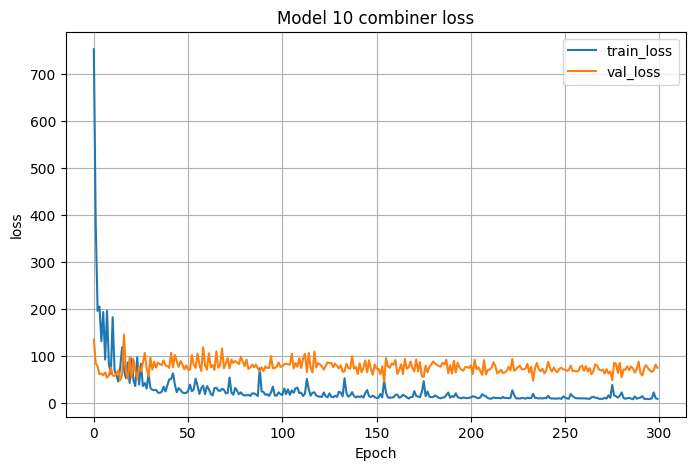

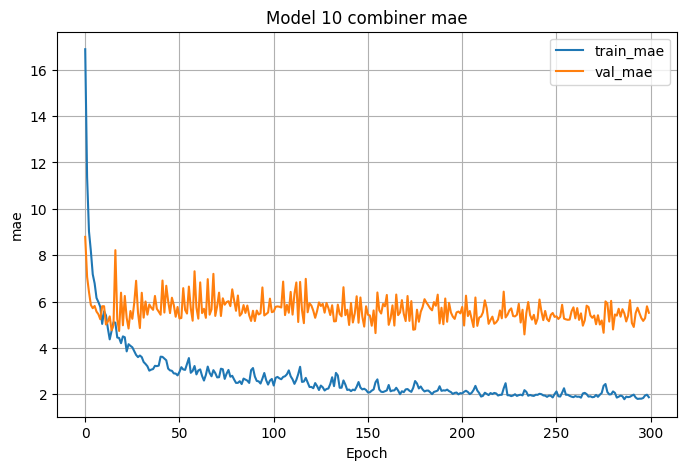

In [ ]:
for metric in ["loss", "mae"]:
    plt.figure(figsize=(8, 5))
    plt.plot(history_combiner.history[metric], label=f"train_{metric}")
    plt.plot(history_combiner.history[f"val_{metric}"], label=f"val_{metric}")
    plt.title(f"Model 10 combiner {metric}")
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.legend()
    plt.grid(True)
    plt.show()


Saving final model

In [ ]:
combiner_model.load_weights(str(combiner_best_path))

final_combiner_path = MODEL10_DIR / "final_model10_combiner.keras"
combiner_model.save(final_combiner_path)

summary = {
    "model3_dir": str(MODEL3_DIR),
    "model10_dir": str(MODEL10_DIR),
    "rgb_img_height": RGB_IMG_HEIGHT,
    "rgb_img_width": RGB_IMG_WIDTH,
    "batch_size": BATCH_SIZE,
    "combiner_epochs": COMBINER_EPOCHS,
    "combiner_test_loss": float(combiner_test_results.get("loss")),
    "combiner_test_mae": float(combiner_test_results.get("mae")),
    "combiner_test_mse": float(combiner_test_results.get("mse")),
    "combiner_test_pmae": float(combiner_test_pmae),
    "rgb_only_test_mae": float(rgb_only_mae),
    "rgb_only_test_mse": float(rgb_only_mse),
    "rgb_only_test_pmae": float(rgb_only_pmae),
}

summary_path = MODEL10_DIR / "run_summary_model10.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved final combiner model to:", final_combiner_path)
print("Saved summary to:", summary_path)


Saved final combiner model to: /content/drive/MyDrive/Speciale/Models/Model_10_ViT_overhead_RGB_plus_actual_mass/final_model10_combiner.keras
Saved summary to: /content/drive/MyDrive/Speciale/Models/Model_10_ViT_overhead_RGB_plus_actual_mass/run_summary_model10.json


The next section will move a bit away from deep learning, and instead focus on more regular ML models.

The idea is that since the dataset given the combiner is quite small a simple linear regression could suffice, other models will also be tested such as Mars and XGBoost. The main concern before was that the dataset essentially consist of only two variables with around 3500 observations making it quite a small dataset, that is the reason for trying these models.

Libraries needed

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import joblib
import json
import numpy as np
import pandas as pd

Importing Mars

In [ ]:
try:
    from pyearth import Earth
    MARS_AVAILABLE = True
    print("MARS available.")
except Exception:
    MARS_AVAILABLE = False
    print("MARS not available.")
    print("Run this cell if needed:")
    print("!pip install sklearn-contrib-py-earth")

MARS not available.
Run this cell if needed:
!pip install sklearn-contrib-py-earth


In [ ]:
!pip install sklearn-contrib-py-earth
from pyearth import Earth
MARS_AVAILABLE = True

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.3 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


ModuleNotFoundError: No module named 'pyearth'

In [ ]:
def compute_pmae(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)
    return float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100.0)


def evaluate_predictions(name, y_true, y_pred):
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    return {
        "model": name,
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "mse": float(mean_squared_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
        "pmae": float(compute_pmae(y_true, y_pred))
    }

Fitting individual combiners

In [ ]:
models = {}

# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
models["LinearRegression"] = lr_model

# MARS
if MARS_AVAILABLE:
    mars_model = Earth(
        max_degree=1,
        penalty=3.0
    )
    mars_model.fit(X_train, y_train)
    models["MARS"] = mars_model

# XGBoost
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=2,
    learning_rate=0.03,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_alpha=0.0,
    reg_lambda=1.0,
    objective="reg:squarederror",
    random_state=SEED
)
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)
models["XGBoost"] = xgb_model

print("Fitted models:", list(models.keys()))

Fitted models: ['LinearRegression', 'XGBoost']


Generating predictions

In [ ]:
train_preds = {}
val_preds = {}
test_preds = {}

for model_name, model in models.items():
    train_preds[model_name] = model.predict(X_train).reshape(-1)
    val_preds[model_name]   = model.predict(X_val).reshape(-1)
    test_preds[model_name]  = model.predict(X_test).reshape(-1)

Ensemble model for all three

In [ ]:
ensemble_model_names = list(models.keys())

train_preds["Ensemble_Average"] = np.mean(
    np.column_stack([train_preds[m] for m in ensemble_model_names]),
    axis=1
)

val_preds["Ensemble_Average"] = np.mean(
    np.column_stack([val_preds[m] for m in ensemble_model_names]),
    axis=1
)

test_preds["Ensemble_Average"] = np.mean(
    np.column_stack([test_preds[m] for m in ensemble_model_names]),
    axis=1
)

print("Ensemble built from:", ensemble_model_names)

Ensemble built from: ['LinearRegression', 'XGBoost']


Evaluation of all the models

In [ ]:
results = []

results.append({
    "model": "RGB_only_baseline",

    "train_mae": float(mean_absolute_error(y_train, train_combiner_df["rgb_carb_pred"])),
    "train_mse": float(mean_squared_error(y_train, train_combiner_df["rgb_carb_pred"])),
    "train_rmse": float(np.sqrt(mean_squared_error(y_train, train_combiner_df["rgb_carb_pred"]))),
    "train_r2": float(r2_score(y_train, train_combiner_df["rgb_carb_pred"])),
    "train_pmae": float(compute_pmae(y_train, train_combiner_df["rgb_carb_pred"])),

    "val_mae": float(mean_absolute_error(y_val, val_combiner_df["rgb_carb_pred"])),
    "val_mse": float(mean_squared_error(y_val, val_combiner_df["rgb_carb_pred"])),
    "val_rmse": float(np.sqrt(mean_squared_error(y_val, val_combiner_df["rgb_carb_pred"]))),
    "val_r2": float(r2_score(y_val, val_combiner_df["rgb_carb_pred"])),
    "val_pmae": float(compute_pmae(y_val, val_combiner_df["rgb_carb_pred"])),

    "test_mae": float(mean_absolute_error(y_test, test_combiner_df["rgb_carb_pred"])),
    "test_mse": float(mean_squared_error(y_test, test_combiner_df["rgb_carb_pred"])),
    "test_rmse": float(np.sqrt(mean_squared_error(y_test, test_combiner_df["rgb_carb_pred"]))),
    "test_r2": float(r2_score(y_test, test_combiner_df["rgb_carb_pred"])),
    "test_pmae": float(compute_pmae(y_test, test_combiner_df["rgb_carb_pred"]))
})

for model_name in list(models.keys()) + ["Ensemble_Average"]:
    results.append({
        "model": model_name,

        "train_mae": float(mean_absolute_error(y_train, train_preds[model_name])),
        "train_mse": float(mean_squared_error(y_train, train_preds[model_name])),
        "train_rmse": float(np.sqrt(mean_squared_error(y_train, train_preds[model_name]))),
        "train_r2": float(r2_score(y_train, train_preds[model_name])),
        "train_pmae": float(compute_pmae(y_train, train_preds[model_name])),

        "val_mae": float(mean_absolute_error(y_val, val_preds[model_name])),
        "val_mse": float(mean_squared_error(y_val, val_preds[model_name])),
        "val_rmse": float(np.sqrt(mean_squared_error(y_val, val_preds[model_name]))),
        "val_r2": float(r2_score(y_val, val_preds[model_name])),
        "val_pmae": float(compute_pmae(y_val, val_preds[model_name])),

        "test_mae": float(mean_absolute_error(y_test, test_preds[model_name])),
        "test_mse": float(mean_squared_error(y_test, test_preds[model_name])),
        "test_rmse": float(np.sqrt(mean_squared_error(y_test, test_preds[model_name]))),
        "test_r2": float(r2_score(y_test, test_preds[model_name])),
        "test_pmae": float(compute_pmae(y_test, test_preds[model_name]))
    })

results_df = pd.DataFrame(results).sort_values("val_mae", ascending=True).reset_index(drop=True)
display(results_df)

,model,train_mae,train_mse,train_rmse,train_r2,train_pmae,val_mae,val_mse,val_rmse,val_r2,val_pmae,test_mae,test_mse,test_rmse,test_r2,test_pmae
0,RGB_only_baseline,1.432568,6.344157,2.518761,0.988113,46685420.0,4.529927,44.718330,6.687177,0.803660,41.919495,4.765221,57.263653,7.567275,0.811340,162322224.0
1,LinearRegression,1.403651,5.230897,2.287115,0.990199,85391496.0,4.589441,44.643436,6.681574,0.803988,52.502422,4.895701,58.369160,7.639971,0.807698,240826080.0
2,Ensemble_Average,1.656056,6.215442,2.493079,0.988354,116137488.0,4.652565,44.642570,6.681510,0.803992,50.443829,5.028954,60.273682,7.763613,0.801423,280212096.0
3,XGBoost,2.062464,10.416134,3.227404,0.980483,146883472.0,4.787367,45.652161,6.756638,0.799559,49.427128,5.229654,63.262913,7.953799,0.791575,319598112.0


Saving comparison

In [ ]:
results_csv = MODEL10_DIR / "classical_combiner_comparison.csv"
results_df.to_csv(results_csv, index=False)
print("Saved results to:", results_csv)

Saved results to: /content/drive/MyDrive/Speciale/Models/Model_10_ViT_overhead_RGB_plus_actual_mass/classical_combiner_comparison.csv


Saving trained models

In [ ]:
joblib.dump(lr_model, MODEL10_DIR / "combiner_linear_regression.joblib")
print("Saved LR model.")

if "MARS" in models:
    joblib.dump(models["MARS"], MODEL10_DIR / "combiner_mars.joblib")
    print("Saved MARS model.")

joblib.dump(xgb_model, MODEL10_DIR / "combiner_xgboost.joblib")
print("Saved XGBoost model.")

Saved LR model.
Saved XGBoost model.


In [ ]:
test_results_df = test_combiner_df.copy()

test_results_df["rgb_only_pred"] = test_combiner_df["rgb_carb_pred"]

if "LinearRegression" in test_preds:
    test_results_df["lr_pred"] = test_preds["LinearRegression"]

if "MARS" in test_preds:
    test_results_df["mars_pred"] = test_preds["MARS"]

if "XGBoost" in test_preds:
    test_results_df["xgb_pred"] = test_preds["XGBoost"]

test_results_df["ensemble_pred"] = test_preds["Ensemble_Average"]

best_model_name = results_df.iloc[0]["model"]
print("Best model by validation MAE:", best_model_name)

if best_model_name == "RGB_only_baseline":
    test_results_df["final_pred"] = test_results_df["rgb_only_pred"]
elif best_model_name == "LinearRegression":
    test_results_df["final_pred"] = test_results_df["lr_pred"]
elif best_model_name == "MARS":
    test_results_df["final_pred"] = test_results_df["mars_pred"]
elif best_model_name == "XGBoost":
    test_results_df["final_pred"] = test_results_df["xgb_pred"]
elif best_model_name == "Ensemble_Average":
    test_results_df["final_pred"] = test_results_df["ensemble_pred"]

test_results_df["abs_error"] = np.abs(test_results_df["total_carb"] - test_results_df["final_pred"])
test_results_df["abs_error_rgb_only"] = np.abs(test_results_df["total_carb"] - test_results_df["rgb_only_pred"])

predictions_csv = MODEL10_DIR / "test_predictions_all_classical_combiners.csv"
test_results_df.to_csv(predictions_csv, index=False)

print("Saved test predictions to:", predictions_csv)
display(test_results_df.head())

Best model by validation MAE: RGB_only_baseline
Saved test predictions to: /content/drive/MyDrive/Speciale/Models/Model_10_ViT_overhead_RGB_plus_actual_mass/test_predictions_all_classical_combiners.csv


,dish_id,total_carb,total_mass,rgb_carb_pred,rgb_only_pred,lr_pred,xgb_pred,ensemble_pred,final_pred,abs_error,abs_error_rgb_only
0,dish_1556575327,10.618,152.0,12.507236,12.507236,13.095013,12.918564,13.006788,12.507236,1.889236,1.889236
1,dish_1557861216,0.000,1.0,1.025138,1.025138,1.965915,1.006387,1.486151,1.025138,1.025138,1.025138
2,dish_1557862345,0.000,63.0,1.074629,1.074629,2.086478,3.071275,2.578876,1.074629,1.074629,1.074629
3,dish_1557862696,3.850,77.0,3.543902,3.543902,4.457979,4.774719,4.616349,3.543902,0.306098,0.306098
4,dish_1557862738,0.000,118.0,4.563577,4.563577,5.478952,6.355424,5.917188,4.563577,4.563577,4.563577


Top 10 best and worst dishes

In [ ]:
best_10 = test_results_df.sort_values("abs_error", ascending=True).head(10)
worst_10 = test_results_df.sort_values("abs_error", ascending=False).head(10)

print("Top 10 best predictions:")
display(best_10[[
    "dish_id", "total_carb", "total_mass",
    "rgb_only_pred", "final_pred", "abs_error"
]])

print("Top 10 worst predictions:")
display(worst_10[[
    "dish_id", "total_carb", "total_mass",
    "rgb_only_pred", "final_pred", "abs_error"
]])

Top 10 best predictions:


,dish_id,total_carb,total_mass,rgb_only_pred,final_pred,abs_error
54,dish_1558376801,0.795000,15.0,0.798961,0.798961,0.003961
336,dish_1563909507,8.186116,151.0,8.204203,8.204203,0.018087
351,dish_1563998323,35.302532,574.0,35.333618,35.333618,0.031086
289,dish_1562790775,1.519515,40.0,1.554551,1.554551,0.035036
61,dish_1558461760,2.379000,61.0,2.339917,2.339917,0.039083
489,dish_1567007751,9.660000,87.0,9.620059,9.620059,0.039941
477,dish_1566850031,25.780001,662.0,25.725090,25.725090,0.054911
17,dish_1557937758,18.932001,128.0,18.995913,18.995913,0.063912
429,dish_1565898158,10.249402,194.0,10.319388,10.319388,0.069986
122,dish_1559578551,0.322000,23.0,0.244068,0.244068,0.077932


Top 10 worst predictions:


,dish_id,total_carb,total_mass,rgb_only_pred,final_pred,abs_error
178,dish_1560801020,61.690983,250.0,27.431894,27.431894,34.259089
179,dish_1560801041,63.245892,292.0,29.548124,29.548124,33.697768
149,dish_1560367952,45.956913,221.0,13.091601,13.091601,32.865312
177,dish_1560800988,61.249092,230.0,28.556852,28.556852,32.692240
150,dish_1560367980,47.243912,254.0,16.448000,16.448000,30.795912
247,dish_1562009934,62.243580,369.0,33.657280,33.657280,28.586300
313,dish_1563478751,54.133282,545.0,25.818369,25.818369,28.314913
446,dish_1566328805,85.054001,488.0,57.366875,57.366875,27.687126
318,dish_1563551220,79.790924,558.0,52.106049,52.106049,27.684875
325,dish_1563566909,46.750000,187.0,20.878225,20.878225,25.871775


Saving summary file

In [ ]:
summary = {
    "available_models": list(models.keys()) + ["Ensemble_Average"],
    "best_model_by_val_mae": str(best_model_name),
    "results_sorted_by_val_mae": results_df.to_dict(orient="records")
}

summary_path = MODEL10_DIR / "classical_combiner_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=2)

print("Saved summary to:", summary_path)

Saved summary to: /content/drive/MyDrive/Speciale/Models/Model_10_ViT_overhead_RGB_plus_actual_mass/classical_combiner_summary.json
